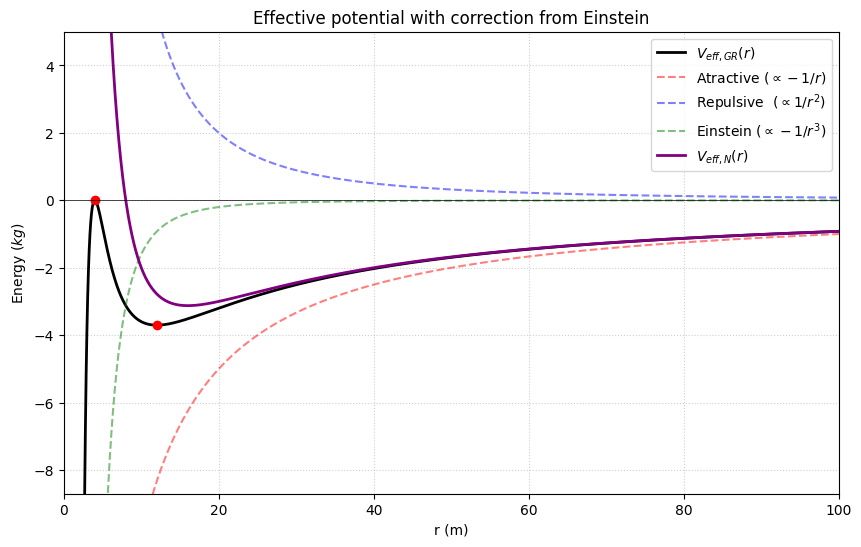

In [2]:
import numpy as np
import matplotlib.pyplot as plt
#import matplotlib as mpl
#mpl.rcParams['figure.dpi'] = 600

# Constants for a nice plot
m = 100.0    # Mass
k = 1.0      # Constant  k = G * M
c = 1        # Speed of light
l = 4*k/c    # Angular momentum per unit mass

def effective_potential_einstein(r):
    attractive = -m * k / r
    repulsive = (m * l**2) / (2 * r**2)
    einstein = -(m * k * l**2) / ((c**2)*(r**3))
    return attractive + repulsive  + einstein

def effective_potential_newton(r):
    attractive = -m * k / r
    repulsive  = (m * l**2) / (2 * r**2)
    return attractive + repulsive

# Define the range of r (avoid Schwarzschild's radius)
r = np.linspace(2*k/(c**2), 100.0, 2000)
v_eff_einstein = effective_potential_einstein(r)
v_eff_newton = effective_potential_newton(r)

# Compute the max and min r for the orbit
r_max = 4*k/(c**2)
v_max = effective_potential_einstein(r_max)
r_stable = 12*k/(c**2)
v_stable = effective_potential_einstein(r_stable)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(r, v_eff_einstein, label=r'$V_{eff, GR}(r)$', color='black', lw=2)

# Add components to show how they combine
plt.plot(r, -m * k / r, '--', label='Atractive ($\\propto -1/r$)', alpha=0.5, color='red')
plt.plot(r, (m * l**2) / (2 * r**2), '--', label='Repulsive  ($\\propto 1/r^2$)', alpha=0.5,color='blue')
plt.plot(r,  -(m * k * l**2) / (r**3), '--', label='Einstein ($\\propto -1/r^3$)', alpha=0.5,color='green')

#Add Newton's plot
plt.plot(r, v_eff_newton, label=r'$V_{eff, N}(r)$', color='purple', lw=2)

# Highlight the stable orbit point
plt.plot(r_stable, v_stable, 'ro')
plt.plot(r_max, v_max, 'ro')

# Formatting the plot
plt.axhline(0, color='black', linewidth=0.5)
plt.xlim(0, 100.0)
plt.ylim(v_stable - 5, 5)
plt.xlabel('r (m)')
plt.ylabel('Energy $(kg)$') # Why would the energy be in kg's? (Hint: look at what we did with the speed of light!)
plt.title('Effective potential with correction from Einstein')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()